In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import airy

In [17]:
#CONSTANTS
c = 299792458.0
e = 1.60217663e-19
eps0 = 8.854187812e-12
m_e_MeV = 0.51099895

In [18]:
#ARES ENERGY PARAMETERS
E_MeV = 100
E_total = E_MeV + m_e_MeV
gamma = E_total / m_e_MeV
beta = np.sqrt(1 - 1 / gamma**2)
v = beta * c

In [19]:
#ARES CHARGE PARAMETERS
bunchcharge = 5e-12
Ne = bunchcharge/e

In [20]:
#BEAM PARAMETERS - OAM + GAUSSIAN
sigma_x = sigma_y = 100-6

In [21]:
#TEMPORAL PULSE (in sec)
sigma_t = 1e-12

In [22]:
#SIGMA Z FOR GAUSSIAN
sigma_z = c * sigma_t

In [23]:
#OBSERVATION GRIDS
Nangle, Nlam = 200, 3000
th = np.linspace(-0.4, 0.4, Nangle)
lam = np.linspace(1e-7,1e-6, Nlam)
TH, LAM = np.meshgrid(th, lam, indexing='ij')
phi = np.linspace(0, 2*np.pi, Nangle, endpoint=False)
omega = 2*np.pi*c/lam

In [24]:
# #SINGLE ELECTRON SPECTRUM
A = e**2 / (4*np.pi * eps0 * c)
W1 = A*(beta**2 * np.sin(TH)**2) / (1.0 - beta**2 * np.cos(TH)**2)**2

In [25]:
#BUILDING GAUSSIAN DIST
def rho_gaussian_3d(x, y, z, sigma_x, sigma_z):
    r2 = x**2 + y**2
    return np.exp((-(r2) / (2*sigma_x**2)) - (z**2 / (2*sigma_z**2)))

x_g = np.linspace(-sigma_t, sigma_t, 200)
y_g = np.linspace(-sigma_t, sigma_t, 200)
z_g = np.linspace(-8*sigma_z, 8*sigma_z, 200) 
rho_g = rho_gaussian_3d(x_g, y_g, z_g, sigma_x, sigma_z)

In [26]:
#BUILDING OAM DIST
def rho_oam_3d(x, y, z, sigma_x, sigma_z, l):
    r2 = x**2 + y**2
    return (r2**l) * np.exp((-(r2) / (2*sigma_x**2)) - (z**2 / (2*sigma_z**2)))

x_o = np.linspace(-sigma_t, sigma_t, 200)
y_o = np.linspace(-sigma_t, sigma_t, 200)
z_o = np.linspace(-8*sigma_z, 8*sigma_z, 200) 
rho_o = rho_oam_3d(x_o, y_o, z_o, sigma_x, sigma_z, l=2)

In [27]:
#BUILDING AIRY DIST
sigma_x = sigma_y = 1e-3
x   = np.linspace(-sigma_x, sigma_x, 3000)   # plus or minus 1 mm
z   = np.linspace(0.0, 2.5, 3000)        # prop from 0m to 2.5 m 
rho_z = np.exp(-0.5*(z/sigma_z)**2)
def airy_beam_scaled(x, z, wavelength, x0=sigma_x, a=0.05):
    k = 2*np.pi/wavelength
    X, Z = np.meshgrid(x, z, indexing='ij')
    xi   = X / x0
    zeta = Z / (k * x0**2)
    arg  = xi - (zeta**2)/4 + 1j*a*zeta
    Ai, _, _, _ = airy(arg)
    phase = (xi*zeta)/2 - (zeta**3)/12
    amp   = a*(xi - (zeta**2)/2)

    psi = Ai * np.exp(amp + 1j*phase)
    return psi, X, Z

# x   = np.linspace(-sigma_x, sigma_x, 1400)   # plus or minus 1 mm
# z   = np.linspace(0.0, 2.5, 1200)        # prop from 0m to 2.5 m 
E, X, Z = airy_beam_scaled(x, z, lam, x0=2e-4, a=0.05)
I = np.abs(E)**2
I /= I.max()

In [28]:
#FORM FACTOR
def f2(omega, theta, rho_z, z, beta):
    dz = z[1] - z[0]
    rho = rho_z / np.trapz(rho_z, z)

    Rk = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho))) * dz
    kz = np.fft.fftshift(2*np.pi*np.fft.fftfreq(z.size, d=dz))

    Rk /= Rk[np.argmin(np.abs(kz))]

    k = omega / c
    kz_target = k[None, :] * (1.0/beta - np.cos(theta)[:, None])
    
    kz_flat = np.clip(kz_target.ravel(), kz[0], kz[-1])
    f2 = np.interp(kz_flat, kz, np.abs(Rk)**2).reshape(kz_target.shape)
    return f2

In [29]:
#CALCULATING BUNCH SPECTRUM
def electron_bunch_spectrum(W1, Ne, omega, th, rho_z, z, beta):
    Wn_list = []
    F2 = f2(omega, th, rho_z, z, beta)
    Wn_list.append(W1 * (Ne + Ne*(Ne-1)*F2))
    stack = np.stack(Wn_list, axis=0)
    positive = stack[stack > 0]
    vmin = np.percentile(positive, 1) if positive.size else 1e-30
    vmax = stack.max()
    
    return Wn_list, vmin, vmax, F2

In [30]:
Wn_list_g, vmin_g, vmax_g, F2_g = electron_bunch_spectrum(W1, Ne, omega, th, rho_g, z_g, beta)
Wn_list_o, vmin_o, vmax_o, F2_o = electron_bunch_spectrum(W1, Ne, omega, th, rho_o, z_o, beta)
Wn_list_a, vmin_a, vmax_a, F2_a = electron_bunch_spectrum(W1, Ne, omega, th, I[0], z, beta)

In [31]:
#PLOTTING
def plot_ctr_spectrum(th, lam, Wn_list, vmin, vmax, sigma_t):
    fig, ax = plt.subplots(figsize=(6,4))  
    im = ax.pcolormesh(th, lam, np.maximum(Wn_list[0].T, vmin), shading='auto', cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
    
    ax.set_title(f'CTR \nPulse Duration \n = {sigma_t:.2e} s')
    ax.set_xlabel(r'$\theta$ (rad)')
    ax.set_ylabel(r'$\lambda$ (m)')
    ax.set_ylim(lam.min(), lam.max())
    
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r'$W_n$ (LogNorm)')

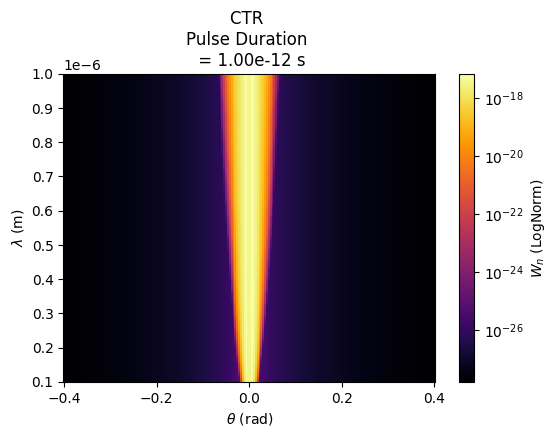

In [32]:
plot_ctr_spectrum(th, lam, Wn_list_g, vmin_g, vmax_g, sigma_t)

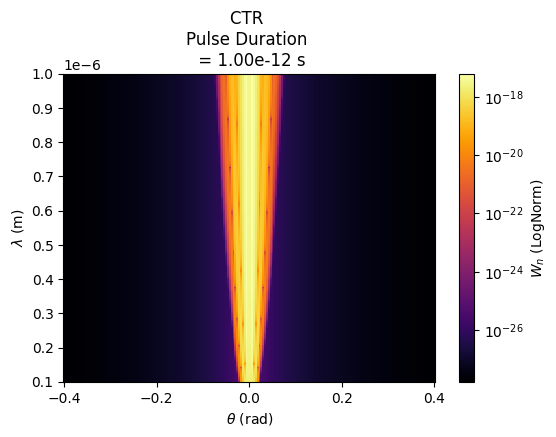

In [33]:
plot_ctr_spectrum(th, lam, Wn_list_o, vmin_o, vmax_o, sigma_t)

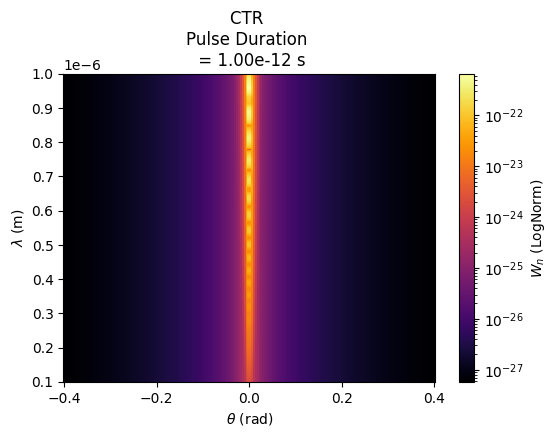

In [34]:
plot_ctr_spectrum(th, lam, Wn_list_a, vmin_a, vmax_a, sigma_t)

In [37]:
#INTEGRATION OF WN WITH RESPECT TO BIG OMEGA
def integrate_Wn_over_Omega(Wn_list, sigma_t, th, TH, lam, logscale=True):
    jac = 2 * np.pi * np.sin(TH)
    Wn_int = [np.trapz(np.abs(Wn * jac), th, axis=0) for Wn in Wn_list]
    Wn_int_array = np.array(Wn_int)
    plt.figure(figsize=(6,4))
    for i, spectrum in enumerate(Wn_int_array):
        plt.plot(lam, spectrum)
    if logscale:
        plt.yscale('log')
    plt.xlabel(r'$\lambda$ [m]')
    plt.ylabel('Photon Count (Scaled)')
    plt.title(f"Photon Count from CTR at Pulse Duration \n = {sigma_t:.2e} s")

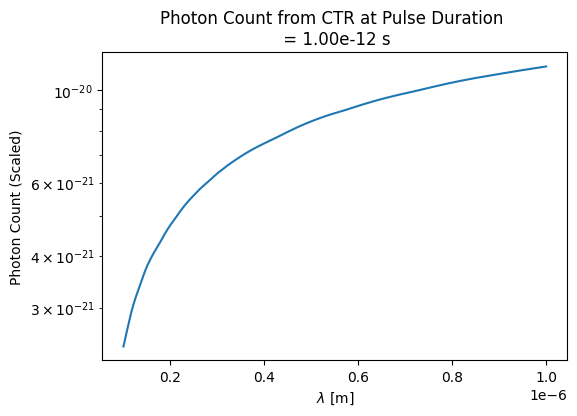

In [38]:
integrate_Wn_over_Omega(Wn_list_g, sigma_t, th, TH, lam)

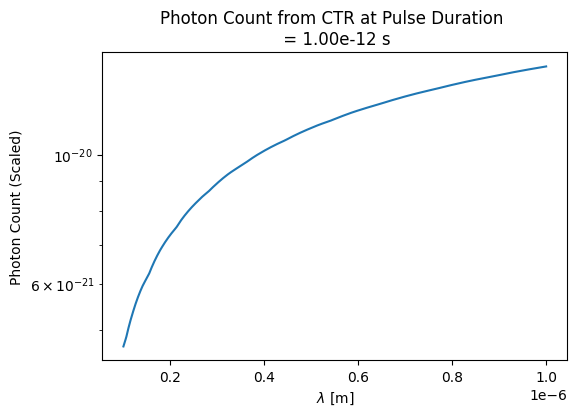

In [ ]:
integrate_Wn_over_Omega(Wn_list_o, sigma_t, th, TH, lam)

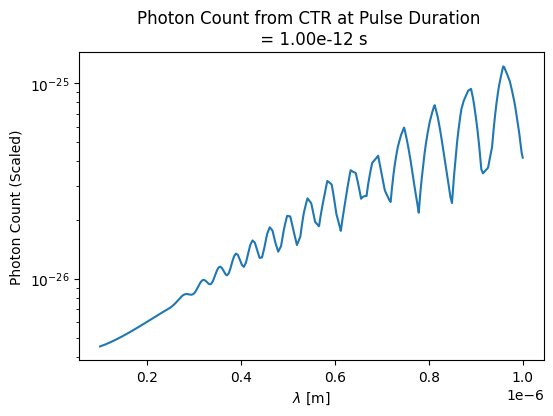

In [ ]:
integrate_Wn_over_Omega(Wn_list_a, sigma_t, th, TH, lam)